##### Implementing: [Playlist](https://www.youtube.com/playlist?list=PLa14hsXP1CHRya4B4sK234p9YBB-Tgbqm)

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import time

### Loading and making the datset compatible with everything

In [2]:
dataset_train = pd.read_csv('leaf-classification/train.csv')
dataset_test = pd.read_csv('leaf-classification/test.csv')

dataset_train.shape, dataset_test.shape

((990, 194), (594, 193))

In [3]:
dataset_train.sample(5)

,id,species,margin1,margin2,margin3,margin4,margin5,margin6,margin7,margin8,...,texture55,texture56,texture57,texture58,texture59,texture60,texture61,texture62,texture63,texture64
800,1283,Quercus_Cerris,0.007812,0.005859,0.013672,0.042969,0.007812,0.000000,0.005859,0.0,...,0.000000,0.000000,0.000977,0.000977,0.026367,0.00000,0.0,0.003906,0.012695,0.063477
946,1519,Acer_Mono,0.025391,0.013672,0.025391,0.009766,0.003906,0.007812,0.052734,0.0,...,0.228520,0.000000,0.013672,0.000977,0.000977,0.00000,0.0,0.000000,0.000000,0.028320
951,1525,Acer_Capillipes,0.000000,0.000000,0.013672,0.015625,0.035156,0.000000,0.023438,0.0,...,0.096680,0.000000,0.008789,0.000000,0.011719,0.00000,0.0,0.000000,0.021484,0.000977
291,481,Quercus_Rhysophylla,0.041016,0.035156,0.011719,0.023438,0.000000,0.029297,0.013672,0.0,...,0.000000,0.013672,0.000000,0.012695,0.011719,0.00293,0.0,0.096680,0.015625,0.000000
720,1159,Acer_Opalus,0.019531,0.041016,0.046875,0.009766,0.001953,0.046875,0.078125,0.0,...,0.006836,0.000000,0.006836,0.000977,0.019531,0.00000,0.0,0.005859,0.002930,0.011719


In [4]:
X = dataset_train.drop(columns=['id', 'species']).values
y = dataset_train['species'].values
X_test = dataset_test.drop(columns=['id']).values
X.shape, y.shape, X_test.shape

((990, 192), (990,), (594, 192))

In [5]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

X_train, X_valid, y_train, y_valid = train_test_split(X, y_encoded, test_size=0.2, random_state=123)

X_train.shape, y_train.shape, X_valid.shape, y_valid.shape

((792, 192), (792,), (198, 192), (198,))

### Borrowing from Simple Decision Tree, but vectorizing it

In [6]:
class Node:
    def __init__(self, feature_idx=None, threshold=None, info_gain=None, left=None, right=None, value=None):
        # A Node can either be a Decision Node or a Pure Node
        
        # Decision Node: Splitting data based on a feature with some threshold
        self.feature_idx = feature_idx
        self.threshold = threshold
        self.info_gain = info_gain
        self.left = left
        self.right = right

        # Leaf Node: Pure, hence only has which class it belongs to
        self.value = value

In [7]:
class DecisionTree:
    def __init__(self, min_samples_split=2, max_depth=2):
        # Min Samples for splitting to occur
        self.min_samples_split=min_samples_split
        # Max depth for base case and preventing overfitting
        self.max_depth = max_depth

    def build_tree(self, X, y, curr_depth=0):
        n_samples, n_features = X.shape

        # Must not be base condition 
        if n_samples >= self.min_samples_split and curr_depth < self.max_depth:
            best_split = self.best_split(X, y)

            # Ensuring not a pure node, and no feature exhaustion
            if best_split["info_gain"] > 0:
                left_node = self.build_tree(best_split["left_X"], best_split["left_y"], curr_depth + 1)
                right_node = self.build_tree(best_split["right_X"], best_split["right_y"], curr_depth + 1)

                return Node(best_split["feature_idx"], best_split["threshold"], best_split["info_gain"], left_node, right_node)

        # Returning a Pure Node with Majority class
        classes, counts = np.unique(y, return_counts=True)
        leaf_value = classes[np.argmax(counts)]
        return Node(value=leaf_value)

    # Can be Vectorized as well
    def predict(self, X):
        predictions = [self.predict_class(row, self.root) for row in X]
        return predictions

    def predict_class(self, x, node):
        # Leaf Node: Base case
        if node.value is not None:
            return node.value
        # Decision Node
        feature_value = x[node.feature_idx] 
        if feature_value <= node.threshold:
            return self.predict_class(x, node.left)
        else:
            return self.predict_class(x, node.right)

    def fit(self, X, y):
        self.root = self.build_tree(X, y)

#### Fully Vectorized performs worse due to memory bottleneck

In [8]:
def best_split(self, X, y):
    b_split = {
        "feature_idx": None,
        "threshold": None,
        "info_gain": -1,
        "left_X": None,
        "left_y": None,
        "right_X": None,
        "right_y": None
    }

    # This level's entropy remains same, hence shouldn't calc it again and again
    class_labels, counts = np.unique(y, return_counts=True)
    p = counts/len(y)
    y_entropy = np.sum(-p*np.log2(p))

    # y one hot for later finding the count of classes
    y_one_hot = (y.reshape(-1, 1) == np.unique(y)).astype(int) # (rows, 1) == (classes) -> (rows, classes)

    # Trying every possible feature x with every possible threshold to break and find resulting purity
    # X: (rows, features), y: (rows); You first want: Every possible mask for every threshold and every feature
    thresholds = np.unique(X, axis=0)            # (thresholds, features)
    left_mask = X[:, :, None] <= thresholds.T    # (rows, features, 1) <= (features, thresholds) = (rows, features, thresholds)

    # Finding Entropy of the left and right mask:   
    # Entropy = sum_over_classes(-p_i * log(p_i))
    count_left = left_mask.T @ y_one_hot                # (thresholds, rows) @ (rows, classes) = (thresholds, classes)
    count_right = counts - count_left                   # (classes) - (thresholds, classes) = (thresholds, classes)
    total_left = count_left.sum(axis=2, keepdims=True)  # (thresholds, classes).sum(axis=2) = (thresholds)
    total_right = count_right.sum(axis=2, keepdims=True)
    total_left[total_left==0] = 1
    total_right[total_right==0] = 1
    # p_i for a class i = instances of i in the subset / number of classes in the subset
    p_left = count_left / total_left                    # (thresholds, classes)
    p_right = count_right / total_right

    # Need this to make p*log(p) as 0 when p=0: Trick: make p=1 then p*log(p) would be 0
    p_left[p_left==0] = 1
    p_right[p_right==0] = 1
    left_entropy = np.sum(-p_left * np.log2(p_left), axis=2) # (thresholds)
    right_entropy = np.sum(-p_right * np.log2(p_right), axis=2)
    
    # Information gain:
    # Entropy(y) - Weighted Avg Entropy of Children
    info_gain = y_entropy - (total_left[:, :, 0] * left_entropy + total_right[:, :, 0] * right_entropy) / (len(y)) # (thresholds, features)
    
    best_threshold_feature_idx = np.argmax(info_gain)
    best_thresh_idx, best_feature_idx = np.unravel_index(best_threshold_feature_idx, info_gain.shape)
    winning_mask = left_mask[:, best_feature_idx, best_thresh_idx]

    if info_gain[best_thresh_idx, best_feature_idx] > 0 and len(y[winning_mask]) > 0 and len(y[~winning_mask]) > 0:
        b_split["feature_idx"] = best_feature_idx
        b_split["threshold"] = thresholds[best_thresh_idx, best_feature_idx]
        b_split["info_gain"] = info_gain[best_thresh_idx, best_feature_idx]
        b_split["left_X"] = X[winning_mask]
        b_split["left_y"] = y[winning_mask]
        b_split["right_X"] = X[~winning_mask]
        b_split["right_y"] = y[~winning_mask]

    return b_split
DecisionTree.best_split = best_split

In [9]:
start = time.time()
start = time.time()
dt = DecisionTree(max_depth=float('inf'))
dt.fit(X_train, y_train)
end = time.time()

predictions = dt.predict(X_valid)
accuracy = np.mean(predictions == y_valid) * 100
accuracy, end - start

(np.float64(62.121212121212125), 7.247463941574097)

#### Partially Vectorized Model Performs the best

In [10]:
def best_split(self, X, y):
    b_split = {
        "feature_idx": None,
        "threshold": None,
        "info_gain": -1,
        "left_X": None,
        "left_y": None,
        "right_X": None,
        "right_y": None
    }

    # y one hot for later finding the count of classes, as the mask differs from thresh to thresh, need this for rectangular array
    y_one_hot = (y.reshape(-1, 1) == np.unique(y)).astype(int) # (rows, 1) == (classes) -> (rows, classes)
    counts = np.sum(y_one_hot, axis=0)

    # parent entropy remains same
    p = counts/len(y)
    y_entropy = np.sum(-p*np.log2(p))

    for feature_idx in range(X.shape[-1]):

        # Making all masks of feature_idx over all possible thresholds
        thresholds = np.unique(X[:, feature_idx], axis=0)           # (thresholds,)
        left_mask = X[:, feature_idx].reshape(-1, 1) <= thresholds  # (rows, 1) <= (thresholds) = (rows, thresholds)
    
        # Finding Entropy of the left and right mask:   
        # Entropy = sum_over_classes(-p_i * log(p_i))
        count_left = left_mask.T @ y_one_hot                # (thresholds, rows) @ (rows, classes) = (thresholds, classes)
        count_right = counts - count_left                   # (classes) - (thresholds, classes) = (thresholds, classes)
        total_left = count_left.sum(axis=1, keepdims=True)  # (thresholds, classes).sum(axis=2) = (thresholds)
        total_right = count_right.sum(axis=1, keepdims=True)
        total_left[total_left==0] = 1
        total_right[total_right==0] = 1
        # p_i for a class i = instances of i in the subset / number of classes in the subset
        p_left = count_left / total_left                    # (thresholds, classes)
        p_right = count_right / total_right

        # Summing without needing to to make the 0s
        with np.errstate(divide='ignore', invalid='ignore'): 
            left_entropy = np.nansum(-p_left * np.log2(p_left), axis=1) # (thresholds)
            right_entropy = np.nansum(-p_right * np.log2(p_right), axis=1)
    
        # Information gain = Entropy(y) - Weighted Avg Entropy of Children
        info_gain = y_entropy - (total_left[:, 0] * left_entropy + total_right[:, 0] * right_entropy) / (len(y)) # (thresholds)

        best_thresh_idx = np.argmax(info_gain)
        winning_mask = left_mask[:, best_thresh_idx]

        if info_gain[best_thresh_idx] > 0 and winning_mask.sum() > 0 and (~winning_mask).sum() > 0:
            if info_gain[best_thresh_idx] > b_split["info_gain"]:
                b_split["feature_idx"] = feature_idx
                b_split["threshold"] = thresholds[best_thresh_idx]
                b_split["info_gain"] = info_gain[best_thresh_idx]
                b_split["left_X"] = X[winning_mask]
                b_split["left_y"] = y[winning_mask]
                b_split["right_X"] = X[~winning_mask]
                b_split["right_y"] = y[~winning_mask]

    return b_split
DecisionTree.best_split = best_split

In [11]:
start = time.time()
start = time.time()
dt_fast = DecisionTree(max_depth=float('inf'))
dt_fast.fit(X_train, y_train)
end = time.time()

predictions = dt_fast.predict(X_valid)
accuracy = np.mean(predictions == y_valid) * 100
accuracy, end - start

(np.float64(61.61616161616161), 4.523116111755371)

### Our simple DecisionTree with different premitted depths

In [12]:
models = []
accuracies = []
training_times = []

for depth in range(3, 17, 2):
    start = time.time()
    dt = DecisionTree(max_depth = depth)
    dt.fit(X_train, y_train)
    end = time.time()
    predictions = dt.predict(X_valid)
    
    accuracy = np.mean(predictions == y_valid) * 100

    print(f"Model with {depth=} preforming with {accuracy=}%, trained in time: {end - start}s")

    models.append(dt)
    accuracies.append(accuracy)
    training_times.append(end - start)

f"Last Model {accuracy=} at {depth=}"

Model with depth=3 preforming with accuracy=np.float64(2.525252525252525)%, trained in time: 2.656254291534424s
Model with depth=5 preforming with accuracy=np.float64(18.181818181818183)%, trained in time: 2.9136149883270264s
Model with depth=7 preforming with accuracy=np.float64(54.54545454545454)%, trained in time: 3.512850046157837s
Model with depth=9 preforming with accuracy=np.float64(61.61616161616161)%, trained in time: 4.271501064300537s
Model with depth=11 preforming with accuracy=np.float64(61.61616161616161)%, trained in time: 4.443021059036255s
Model with depth=13 preforming with accuracy=np.float64(61.61616161616161)%, trained in time: 4.417399883270264s
Model with depth=15 preforming with accuracy=np.float64(61.61616161616161)%, trained in time: 4.406874895095825s


'Last Model accuracy=np.float64(61.61616161616161) at depth=15'

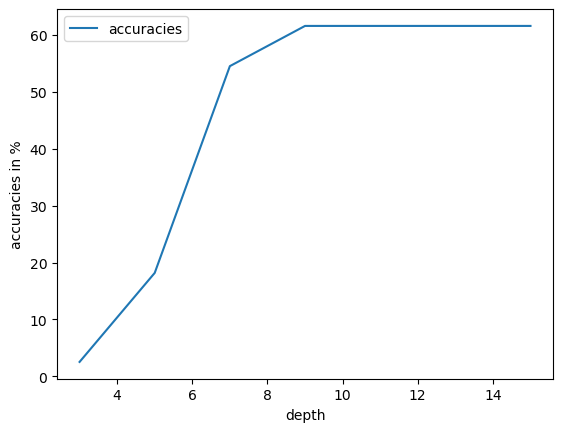

In [13]:
from matplotlib import pyplot as plt

depths = np.arange(3, 17, 2)
plt.plot(depths, accuracies, label='accuracies')
plt.xlabel('depth')
plt.ylabel('accuracies in %')
plt.legend()
plt.show()

### Skelearn DecisionTreeClassifier

In [14]:
from sklearn.tree import DecisionTreeClassifier

start = time.time()
dt_fast = DecisionTreeClassifier(max_depth=None, random_state=123)
dt_fast.fit(X_train, y_train)
end = time.time()

predictions = dt_fast.predict(X_valid)
accuracy = np.mean(predictions == y_valid) * 100
accuracy, end - start

(np.float64(62.62626262626263), 0.23635387420654297)

### Sklearn RandomForestClassifer

In [15]:
from sklearn.ensemble import RandomForestClassifier

start = time.time()
dt_fast = RandomForestClassifier(n_estimators=20, random_state=123, max_depth=None)
dt_fast.fit(X_train, y_train)
end = time.time()

predictions = dt_fast.predict(X_valid)
accuracy = np.mean(predictions == y_valid) * 100
accuracy, end - start

(np.float64(93.93939393939394), 0.1715247631072998)

### Doing the same using XGBoost

In [16]:
from xgboost import XGBClassifier

start = time.time()
xgb = XGBClassifier(max_depth=None, random_state=123).fit(X_train, y_train)
end = time.time()
xgb_predictions = xgb.predict(X_valid)
accuracy = np.mean(xgb_predictions==y_valid)*100
accuracy, end - start

(np.float64(87.37373737373737), 2.786123037338257)

### Implementing Random Forest for Better performance

In [17]:
class RandomForest:
    def __init__(self, num_trees=10, max_depth=4, min_samples_split=2):
         self.trees = []
         self.num_trees = num_trees
         self.max_depth = max_depth
         self.min_samples_split = min_samples_split

    def fit(self, X, y):
        n_rows, n_features = X.shape

        for i in range(self.num_trees):
            dt = DecisionTree(max_depth=self.max_depth, min_samples_split=self.min_samples_split)
            np.random.seed(123 + i)

            # Choose a random subset with replacement
            idxs = np.random.choice(n_rows, n_rows, replace=True)
    
            # Choosing a random set of features to train on
            features = np.random.choice(n_features, int(0.7*n_features), replace=False)

            # Training and adding this model to our arsenal
            X_sample, y_sample = X[idxs][:, features], y[idxs]
            dt.fit(X_sample, y_sample)
            self.trees.append((dt, features))

            print(f"{i} th iteration is done")

    def predict(self, X):

        all_predictions = np.array([dt.predict(X[:, features]) for dt, features in self.trees])

        all_predictions = all_predictions.T

        final_predictions = []

        for row in all_predictions:
            classes, counts = np.unique(row, return_counts=True)
            final_predictions.append(classes[np.argmax(counts)])

        return np.array(final_predictions)
        

In [18]:
start = time.time()
rf = RandomForest(num_trees=20, max_depth=float('inf'))
rf.fit(X_train, y_train)
end = time.time()
end - start

0 th iteration is done
1 th iteration is done
2 th iteration is done
3 th iteration is done
4 th iteration is done
5 th iteration is done
6 th iteration is done
7 th iteration is done
8 th iteration is done
9 th iteration is done
10 th iteration is done
11 th iteration is done
12 th iteration is done
13 th iteration is done
14 th iteration is done
15 th iteration is done
16 th iteration is done
17 th iteration is done
18 th iteration is done
19 th iteration is done


46.38255000114441

In [19]:
np.mean(rf.predict(X_valid) == y_valid)*100

np.float64(87.87878787878788)

### Final Result

|Model| Accuracy(\%) | Time to Train(s)
|--|--|--|
| Simple Scratch Decision Tree (Fully Vectorized)| 62.12 | 7.33
| Simple Scratch Decision Tree (Semi Vectorized) | 61.62 | 4.42
| sklearn DecisionTreeClassifier | 62.62 | 0.23
| sklearn RandomForestClassifier | 93.94 | 0.20
| xgboost XGBClassifier | 87.37 | 2.79
| Simple Scratch Random Forest  | 85.88 | 46.09